# 창원 기온 장기 추세 분석 (1996~2025, 30년)

1차 분석(`analysis.ipynb`, 2023~2025)은 **3년이라 추세를 단정하기 어렵다**는 한계가 있었습니다.
이 노트북은 같은 출처(Open-Meteo)·같은 지점으로 기간을 **30년**으로 늘려, 장기 추세가 있는지 확인합니다.

> 30년을 고른 이유: 기상학에서 '평년값(기후 평균)'을 낼 때 쓰는 표준 기간이 30년이기 때문입니다.

**위에서부터 순서대로** 실행하세요. 공통 함수는 `src/weather_utils.py`에 있습니다.

## 1단계. 준비 — 폴더 위치와 공통 함수 불러오기

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# 이 노트북은 notebooks/ 폴더 안에 있으므로, 한 단계 위(저장소 맨 위)를 기준으로 잡음
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
sys.path.append(str(ROOT / "src"))

from weather_utils import fetch_daily_mean, load_csv, check_quality, yearly_mean, linear_trend, decade_means

DATA_LONG = ROOT / "data" / "changwon_temperature_1996_2025.csv"
DATA_3Y = ROOT / "data" / "changwon_temperature_2023_2025.csv"
IMG = ROOT / "images"

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지 (윈도우)
plt.rcParams["axes.unicode_minus"] = False
print("준비 완료! 저장소 위치:", ROOT)

준비 완료! 저장소 위치: c:\Users\USER\M1-1\weather-timeseries-analysis


## 2단계. 30년치 데이터 수집 (처음 한 번만 인터넷에서 받기)

이미 CSV 파일이 있으면 다시 받지 않고 파일을 그대로 씁니다. (재현성 + 시간 절약)

In [2]:
if DATA_LONG.exists():
    df = load_csv(DATA_LONG)
    print("저장된 파일을 불러왔습니다:", DATA_LONG.name)
else:
    df = fetch_daily_mean("1996-01-01", "2025-12-31")
    df.to_csv(DATA_LONG, index=False, encoding="utf-8-sig")
    print("새로 받아서 저장했습니다:", DATA_LONG.name)

print(df.head())

새로 받아서 저장했습니다: changwon_temperature_1996_2025.csv
          날짜  평균기온
0 1996-01-01   0.7
1 1996-01-02   3.2
2 1996-01-03   2.2
3 1996-01-04  -1.0
4 1996-01-05   2.7


## 3단계. 데이터 품질 확인 + 1차 데이터와 맞는지 검증

- 결측치·날짜 누락·최저/최고를 확인합니다.
- **검증**: 30년 데이터 중 2023~2025 구간이 1차 분석 데이터와 같은 값인지 비교합니다. (같아야 정상)

In [3]:
for k, v in check_quality(df).items():
    print(f"{k}: {v}")

old = load_csv(DATA_3Y)
merged = old.merge(df, on="날짜", suffixes=("_1차", "_30년"))
diff = (merged["평균기온_1차"] - merged["평균기온_30년"]).abs()
print(f"\n[검증] 겹치는 날 {len(merged)}일 중 값이 다른 날: {(diff > 0.05).sum()}일 (최대 차이 {diff.max():.2f}°C)")

기간: 1996-01-01 ~ 2025-12-31
결측치: 0
기간상 날 수: 10958
실제 데이터 수: 10958
최저: -8.3
최고: 31.0

[검증] 겹치는 날 1096일 중 값이 다른 날: 0일 (최대 차이 0.00°C)


## 4단계. 연평균 기온과 장기 추세선

- **연평균**: 해마다 1개의 값 → 계절 반복이 사라져 해마다의 차이만 남습니다.
- **10년 이동평균**: 해마다 들쭉날쭉한 값을 부드럽게 만들어 큰 흐름을 봅니다.
- **추세선(직선)**: 30개 점에 가장 잘 맞는 직선을 그어 "1년에 몇 도씩 변했는지"(기울기)를 구합니다.

추세 기울기: +0.025 °C/년  →  10년에 +0.25 °C,  30년 동안 약 +0.73 °C
30년 평균: 14.22 °C  /  가장 따뜻한 해: 2024년 15.42 °C  /  가장 추운 해: 1996년 13.39 °C
2023년 14.82 °C → 30년 중 따뜻한 순서 3위
2024년 15.42 °C → 30년 중 따뜻한 순서 1위
2025년 14.90 °C → 30년 중 따뜻한 순서 2위


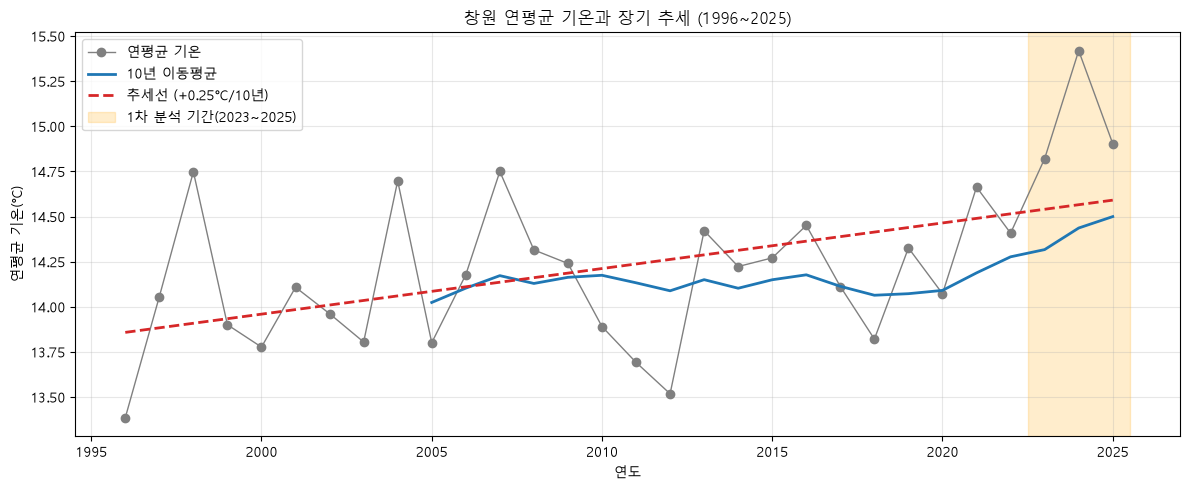

In [4]:
yearly = yearly_mean(df)
slope, fitted = linear_trend(yearly)
ma10 = yearly.rolling(10).mean()

print(f"추세 기울기: {slope:+.3f} °C/년  →  10년에 {slope*10:+.2f} °C,  30년 동안 약 {slope*29:+.2f} °C")
print(f"30년 평균: {yearly.mean():.2f} °C  /  가장 따뜻한 해: {yearly.idxmax()}년 {yearly.max():.2f} °C  /  가장 추운 해: {yearly.idxmin()}년 {yearly.min():.2f} °C")

rank = yearly.rank(ascending=False).astype(int)
for y in [2023, 2024, 2025]:
    print(f"{y}년 {yearly[y]:.2f} °C → 30년 중 따뜻한 순서 {rank[y]}위")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(yearly.index, yearly.values, marker="o", color="gray", linewidth=1, label="연평균 기온")
ax.plot(ma10.index, ma10.values, color="tab:blue", linewidth=2, label="10년 이동평균")
ax.plot(fitted.index, fitted.values, "--", color="tab:red", linewidth=2, label=f"추세선 ({slope*10:+.2f}°C/10년)")
ax.axvspan(2022.5, 2025.5, color="orange", alpha=0.2, label="1차 분석 기간(2023~2025)")
ax.set_title("창원 연평균 기온과 장기 추세 (1996~2025)")
ax.set_xlabel("연도"); ax.set_ylabel("연평균 기온(°C)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG / "09_장기추세_연평균.png", dpi=150, bbox_inches="tight")
plt.show()

## 5단계. 10년 단위 비교

30년을 10년씩 3구간으로 나눠 평균을 비교합니다. 해마다의 들쭉날쭉함이 줄어 변화를 보기 쉽습니다.

1996~2005    14.02
2006~2015    14.15
2016~2025    14.50
dtype: float64

첫 10년 → 마지막 10년 차이: +0.48 °C


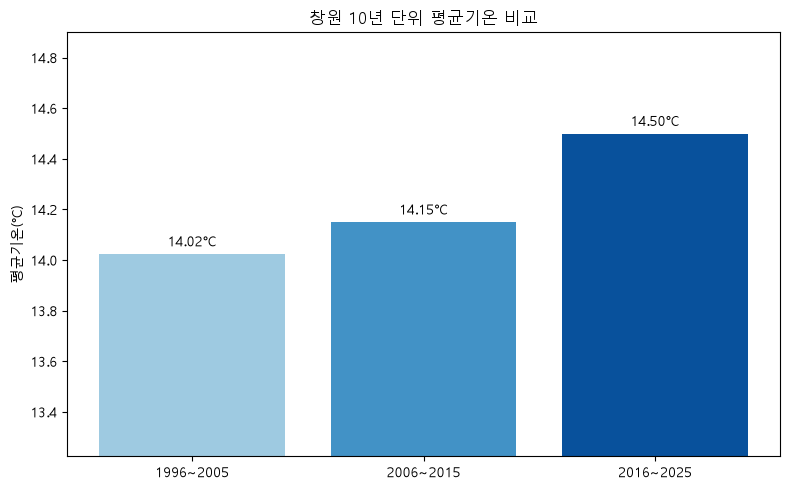

In [5]:
dec = decade_means(yearly)
print(dec.round(2))
print(f"\n첫 10년 → 마지막 10년 차이: {dec.iloc[-1] - dec.iloc[0]:+.2f} °C")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dec.index, dec.values, color=["#9ecae1", "#4292c6", "#08519c"])
for b, v in zip(bars, dec.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.03, f"{v:.2f}°C", ha="center")
ax.set_ylim(dec.min() - 0.8, dec.max() + 0.4)   # 작은 차이를 보기 위해 세로축을 확대 (0부터 시작 아님)
ax.set_title("창원 10년 단위 평균기온 비교")
ax.set_ylabel("평균기온(°C)")
plt.tight_layout()
plt.savefig(IMG / "10_10년단위_평균비교.png", dpi=150, bbox_inches="tight")
plt.show()

## 6단계. 리포트용 요약 (이 출력값을 REPORT.md에 옮겨 씁니다)

In [6]:
print("=== 리포트용 요약 ===")
print(f"데이터: {len(df)}일 ({df['날짜'].min().date()} ~ {df['날짜'].max().date()}), 결측치 {int(df['평균기온'].isna().sum())}개")
print(f"추세: {slope*10:+.2f} °C/10년")
print("10년 평균:", ", ".join(f"{k} {v:.2f}°C" for k, v in dec.items()))
print(f"가장 따뜻한 해 TOP 5: {', '.join(f'{y}({v:.2f})' for y, v in yearly.nlargest(5).items())}")
print(f"2023~2025 순위: " + ", ".join(f"{y}년 {rank[y]}위" for y in [2023, 2024, 2025]))

=== 리포트용 요약 ===
데이터: 10958일 (1996-01-01 ~ 2025-12-31), 결측치 0개
추세: +0.25 °C/10년
10년 평균: 1996~2005 14.02°C, 2006~2015 14.15°C, 2016~2025 14.50°C
가장 따뜻한 해 TOP 5: 2024(15.42), 2025(14.90), 2023(14.82), 2007(14.75), 1998(14.75)
2023~2025 순위: 2023년 3위, 2024년 1위, 2025년 2위
